In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import csv
import random
import shutil
import zipfile
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import save_image
from tqdm import tqdm


ZIP_PATH = "/content/drive/MyDrive/PCB_Missing_Resistor.zip"

EXTRACT_DIR = "/content/PCB_Missing_Resistor_extracted"
PREPARED_DIR = "/content/PCB_Missing_Resistor_prepared"
SAVE_ROOT = "/content/drive/MyDrive/wgan_gp_512_missing_resistor_v3"

IMG_SIZE = 512
Z_DIM = 100

BATCH_SIZE = 4          # nếu bị CUDA out of memory thì đổi thành 2
EPOCHS = 150
LR = 1e-4

CRITIC_ITER = 5
LAMBDA_GP = 10

SAVE_EVERY = 5

GENERATE_TOTAL = 400
SELECT_TOP_K = 40

SEED = 42
RESUME = False          # nếu Colab bị ngắt, đổi thành True để train tiếp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(SAVE_ROOT, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Device:", device)
print("ZIP_PATH:", ZIP_PATH)
print("SAVE_ROOT:", SAVE_ROOT)


Mounted at /content/drive
Device: cuda
ZIP_PATH: /content/drive/MyDrive/PCB_Missing_Resistor.zip
SAVE_ROOT: /content/drive/MyDrive/wgan_gp_512_missing_resistor_v3


In [ ]:
def find_images(root):
    exts = (".png", ".jpg", ".jpeg", ".bmp", ".webp")
    files = []
    for dirpath, _, filenames in os.walk(root):
        for name in filenames:
            if name.lower().endswith(exts):
                files.append(os.path.join(dirpath, name))
    return sorted(files)


if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(
        f"Không tìm thấy {ZIP_PATH}. Hãy upload PCB_Missing_Resistor.zip vào MyDrive."
    )

for d in [EXTRACT_DIR, PREPARED_DIR]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

raw_files = find_images(EXTRACT_DIR)
print("Found raw images:", len(raw_files))

if len(raw_files) == 0:
    raise RuntimeError("File ZIP không có ảnh .png/.jpg/.jpeg/.bmp/.webp")

prepared_count = 0
for src in tqdm(raw_files, desc="Resize to 512"):
    try:
        img = Image.open(src).convert("RGB")
    except Exception as e:
        print("Skip:", src, e)
        continue

    img = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)
    dst = os.path.join(PREPARED_DIR, f"img_{prepared_count:05d}.png")
    img.save(dst)
    prepared_count += 1

print("Prepared images:", prepared_count)

if prepared_count < BATCH_SIZE:
    raise RuntimeError("Số ảnh sau xử lý nhỏ hơn batch size. Hãy kiểm tra ZIP hoặc giảm BATCH_SIZE.")



Found raw images: 760


Resize to 512: 100%|██████████| 760/760 [02:05<00:00,  6.05it/s]

Prepared images: 760


Dataset size: 760
Batch shape: torch.Size([4, 3, 512, 512])


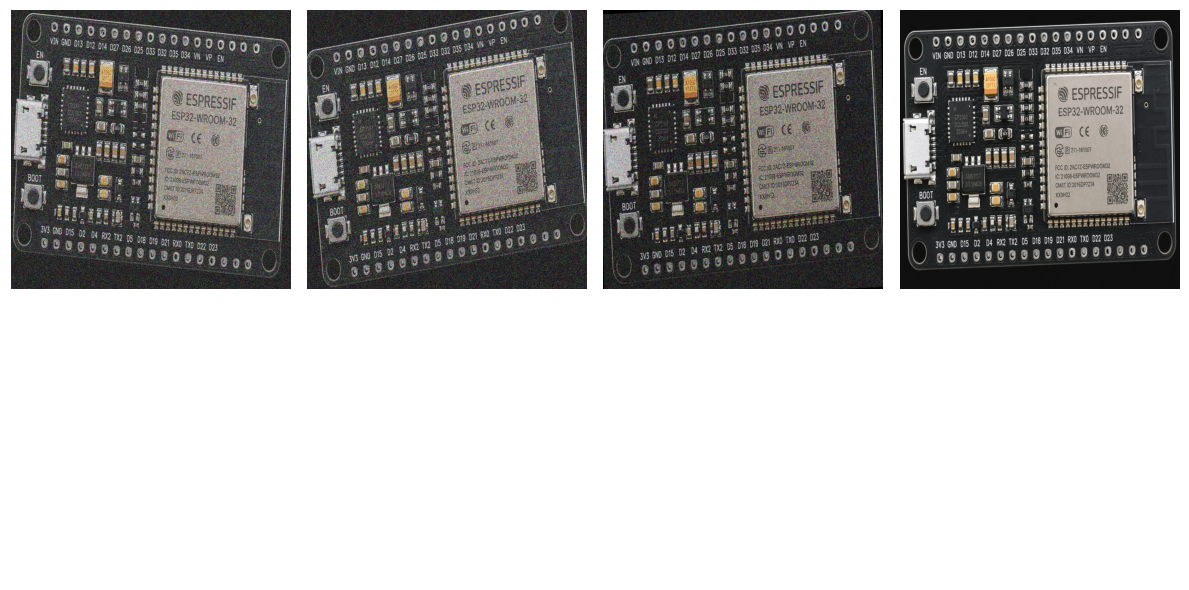

In [ ]:
class PCBDataset(Dataset):
    def __init__(self, root):
        self.files = find_images(root)
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        return self.transform(img)


dataset = PCBDataset(PREPARED_DIR)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
)

print("Dataset size:", len(dataset))

real_preview = next(iter(loader))
print("Batch shape:", real_preview.shape)


def denorm(x):
    return (x * 0.5 + 0.5).clamp(0, 1)


preview = denorm(real_preview[:8]).cpu()
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    if i < preview.size(0):
        ax.imshow(preview[i].permute(1, 2, 0))
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, "dataset_preview.png"), dpi=150)
plt.show()


In [ ]:
class Generator(nn.Module):
    """
    Output: 512x512
    z: [B, 100, 1, 1]
    """
    def __init__(self, z_dim=100):
        super().__init__()

        self.net = nn.Sequential(
            # 1 -> 4
            nn.ConvTranspose2d(z_dim, 1024, 4, 1, 0, bias=False),
            nn.BatchNorm2d(1024),
            nn.ReLU(True),

            # 4 -> 8
            nn.ConvTranspose2d(1024, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # 8 -> 16
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 16 -> 32
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 32 -> 64
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 64 -> 128
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            # 128 -> 256
            nn.ConvTranspose2d(32, 16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(True),

            # 256 -> 512
            nn.ConvTranspose2d(16, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


class Critic(nn.Module):
    """
    Input: 512x512
    Output: score scalar per image
    """
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            # 512 -> 256
            nn.Conv2d(3, 16, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 256 -> 128
            nn.Conv2d(16, 32, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(32, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # 128 -> 64
            nn.Conv2d(32, 64, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(64, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 -> 32
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(128, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 -> 16
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(256, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # 16 -> 8
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(512, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # 8 -> 4
            nn.Conv2d(512, 512, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(512, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # 4 -> 1
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1)


def weights_init(m):
    name = m.__class__.__name__
    if "Conv" in name:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in name:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


G = Generator(Z_DIM).to(device)
D = Critic().to(device)

G.apply(weights_init)
D.apply(weights_init)

g_opt = optim.Adam(G.parameters(), lr=LR, betas=(0.0, 0.9))
d_opt = optim.Adam(D.parameters(), lr=LR, betas=(0.0, 0.9))

with torch.no_grad():
    test = G(torch.randn(1, Z_DIM, 1, 1).to(device))
print("Fake test shape:", test.shape)

Fake test shape: torch.Size([1, 3, 512, 512])


In [ ]:
def gradient_penalty(critic, real, fake):
    batch = real.size(0)
    alpha = torch.rand(batch, 1, 1, 1, device=device)
    mixed = alpha * real + (1 - alpha) * fake
    mixed.requires_grad_(True)

    mixed_scores = critic(mixed)

    grad = torch.autograd.grad(
        inputs=mixed,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    grad = grad.view(batch, -1)
    grad_norm = grad.norm(2, dim=1)
    gp = ((grad_norm - 1) ** 2).mean()
    return gp


def save_samples(epoch, fixed_noise, prefix="epoch"):
    G.eval()
    with torch.no_grad():
        fake = G(fixed_noise).cpu()

    path = os.path.join(SAVE_ROOT, f"samples_{prefix}_{epoch:03d}.png")
    save_image(fake, path, normalize=True, nrow=4)
    G.train()
    return path


def plot_curve(x, y, title, ylabel, filename):
    if len(x) == 0:
        return
    plt.figure(figsize=(9, 5))
    plt.plot(x, y, marker="o", linewidth=1.5, markersize=3)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_ROOT, filename), dpi=150)
    plt.close()


def plot_all(history):
    e = history["epoch"]
    if len(e) == 0:
        return

    plot_curve(e, history["critic_loss"], "Critic Loss", "Loss", "critic_loss.png")
    plot_curve(e, history["generator_loss"], "Generator Loss", "Loss", "generator_loss.png")
    plot_curve(e, history["gradient_penalty"], "Gradient Penalty", "GP", "gradient_penalty.png")
    plot_curve(e, history["critic_real"], "Critic Real Score", "Score", "critic_real_score.png")
    plot_curve(e, history["critic_fake"], "Critic Fake Score", "Score", "critic_fake_score.png")
    plot_curve(e, history["wasserstein"], "Estimated Wasserstein Distance", "Distance", "wasserstein_distance.png")

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    data = [
        ("Critic Loss", history["critic_loss"], "Loss"),
        ("Generator Loss", history["generator_loss"], "Loss"),
        ("Gradient Penalty", history["gradient_penalty"], "GP"),
        ("Critic Real", history["critic_real"], "Score"),
        ("Critic Fake", history["critic_fake"], "Score"),
        ("Wasserstein Distance", history["wasserstein"], "Distance"),
    ]

    for ax, (title, values, ylabel) in zip(axes.flatten(), data):
        ax.plot(e, values, marker="o", linewidth=1.5, markersize=3)
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_ROOT, "training_results.png"), dpi=150)
    plt.close()

In [ ]:
checkpoint_path = os.path.join(SAVE_ROOT, "last_checkpoint.pth")

START_EPOCH = 1
best_fake_score = -1e9
best_epoch = 0

if RESUME and os.path.exists(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    G.load_state_dict(ckpt["G"])
    D.load_state_dict(ckpt["D"])
    g_opt.load_state_dict(ckpt["g_opt"])
    d_opt.load_state_dict(ckpt["d_opt"])
    START_EPOCH = ckpt["epoch"] + 1
    best_fake_score = ckpt["best_fake_score"]
    best_epoch = ckpt["best_epoch"]
    print("Resume from epoch:", START_EPOCH)

In [ ]:
fixed_noise = torch.randn(16, Z_DIM, 1, 1, device=device)

csv_path = os.path.join(SAVE_ROOT, "training_log.csv")

if not RESUME or not os.path.exists(csv_path):
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow([
            "epoch",
            "critic_loss",
            "generator_loss",
            "gradient_penalty",
            "critic_real",
            "critic_fake",
            "wasserstein_distance",
            "best_fake_score",
        ])

history = {
    "epoch": [],
    "critic_loss": [],
    "generator_loss": [],
    "gradient_penalty": [],
    "critic_real": [],
    "critic_fake": [],
    "wasserstein": [],
}

print("=" * 60)
print("START TRAINING WGAN-GP 512")
print("Images:", len(dataset))
print("Batch:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("=" * 60)

save_samples(0, fixed_noise, prefix="before_train")

for epoch in range(START_EPOCH, EPOCHS + 1):
    loop = tqdm(loader)

    total_d = 0.0
    total_g = 0.0
    total_gp = 0.0
    total_real = 0.0
    total_fake = 0.0
    steps = 0

    for real in loop:
        real = real.to(device)
        batch_size = real.size(0)

        # Train Critic
        for _ in range(CRITIC_ITER):
            noise = torch.randn(batch_size, Z_DIM, 1, 1, device=device)
            fake = G(noise)

            critic_real = D(real).mean()
            critic_fake = D(fake.detach()).mean()

            gp = gradient_penalty(D, real, fake.detach())
            loss_d = -(critic_real - critic_fake) + LAMBDA_GP * gp

            d_opt.zero_grad()
            loss_d.backward()
            d_opt.step()

        # Train Generator
        noise = torch.randn(batch_size, Z_DIM, 1, 1, device=device)
        fake = G(noise)
        loss_g = -D(fake).mean()

        g_opt.zero_grad()
        loss_g.backward()
        g_opt.step()

        total_d += loss_d.item()
        total_g += loss_g.item()
        total_gp += gp.item()
        total_real += critic_real.item()
        total_fake += critic_fake.item()
        steps += 1

        loop.set_description(f"Epoch [{epoch}/{EPOCHS}]")
        loop.set_postfix(D=f"{loss_d.item():.4f}", G=f"{loss_g.item():.4f}", GP=f"{gp.item():.4f}")

    avg_d = total_d / steps
    avg_g = total_g / steps
    avg_gp = total_gp / steps
    avg_real = total_real / steps
    avg_fake = total_fake / steps
    w_dist = avg_real - avg_fake

    print(
        f"Epoch {epoch:03d} | "
        f"D={avg_d:.4f} | G={avg_g:.4f} | GP={avg_gp:.4f} | "
        f"Real={avg_real:.4f} | Fake={avg_fake:.4f} | W={w_dist:.4f}"
    )

    with open(csv_path, "a", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow([epoch, avg_d, avg_g, avg_gp, avg_real, avg_fake, w_dist, best_fake_score])

    history["epoch"].append(epoch)
    history["critic_loss"].append(avg_d)
    history["generator_loss"].append(avg_g)
    history["gradient_penalty"].append(avg_gp)
    history["critic_real"].append(avg_real)
    history["critic_fake"].append(avg_fake)
    history["wasserstein"].append(w_dist)

    # Save best by average fake critic score
    if avg_fake > best_fake_score:
        best_fake_score = avg_fake
        best_epoch = epoch
        torch.save(G.state_dict(), os.path.join(SAVE_ROOT, "best_G.pth"))
        torch.save(D.state_dict(), os.path.join(SAVE_ROOT, "best_D.pth"))
        save_samples(epoch, fixed_noise, prefix="best")

    torch.save(G.state_dict(), os.path.join(SAVE_ROOT, "last_G.pth"))
    torch.save(D.state_dict(), os.path.join(SAVE_ROOT, "last_D.pth"))

    torch.save(
        {
            "epoch": epoch,
            "best_epoch": best_epoch,
            "best_fake_score": best_fake_score,
            "G": G.state_dict(),
            "D": D.state_dict(),
            "g_opt": g_opt.state_dict(),
            "d_opt": d_opt.state_dict(),
        },
        checkpoint_path,
    )

    if epoch % SAVE_EVERY == 0:
        torch.save(G.state_dict(), os.path.join(SAVE_ROOT, f"G_epoch_{epoch:03d}.pth"))
        torch.save(D.state_dict(), os.path.join(SAVE_ROOT, f"D_epoch_{epoch:03d}.pth"))
        save_samples(epoch, fixed_noise, prefix="epoch")

    plot_all(history)

print("=" * 60)
print("Training finished")
print("Best epoch:", best_epoch)
print("Best fake score:", best_fake_score)
print("=" * 60)

START TRAINING WGAN-GP 512
Images: 760
Batch: 4
Epochs: 150


Epoch [1/150]: 100%|██████████| 190/190 [01:37<00:00,  1.94it/s, D=-523.0013, G=312.7013, GP=11.2844]


Epoch 001 | D=-213.9237 | G=120.4258 | GP=5.5083 | Real=152.1515 | Fake=-116.8557 | W=269.0072


Epoch [2/150]: 100%|██████████| 190/190 [01:43<00:00,  1.83it/s, D=-701.2542, G=635.1875, GP=26.9094]


Epoch 002 | D=-725.4599 | G=456.2567 | GP=18.0715 | Real=449.7472 | Fake=-456.4272 | W=906.1744


...

Epoch 148 | D=-420.3030 | G=1301.0255 | GP=26.2047 | Real=-624.9076 | Fake=-1307.2581 | W=682.3504


Epoch [149/150]: 100%|██████████| 190/190 [01:45<00:00,  1.80it/s, D=-11.1219, G=1714.8765, GP=31.7189]


Epoch 149 | D=-402.3154 | G=1320.3903 | GP=26.2278 | Real=-658.1042 | Fake=-1322.6976 | W=664.5935


Epoch [150/150]: 100%|██████████| 190/190 [01:45<00:00,  1.81it/s, D=228.2213, G=1405.1863, GP=36.9479]


Epoch 150 | D=-371.5797 | G=1298.7220 | GP=29.4618 | Real=-614.2109 | Fake=-1280.4088 | W=666.1979
Training finished
Best epoch: 1
Best fake score: -116.85565262570194


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G = Generator(Z_DIM).to(device)
D = Critic().to(device)

# Ví dụ dùng epoch 110
G.load_state_dict(torch.load(
    "/content/drive/MyDrive/wgan_gp_512_missing_resistor_v3/G_epoch_110.pth",
    map_location=device
))

D.load_state_dict(torch.load(
    "/content/drive/MyDrive/wgan_gp_512_missing_resistor_v3/D_epoch_110.pth",
    map_location=device
))

G.eval()
D.eval()

print("Loaded successfully!")

Loaded successfully!


In [ ]:
import os
import shutil
from torchvision.utils import save_image

SAVE_DIR = "/content/drive/MyDrive/wgan_gp_512_missing_resistor_v3/generated_400"

TOP40 = "/wgan_gp_512_missing_resistor_v3/best_40_generated"

if os.path.exists(SAVE_DIR):
    shutil.rmtree(SAVE_DIR)

os.makedirs(SAVE_DIR)

records = []

with torch.no_grad():

    for i in range(400):

        z = torch.randn(1, Z_DIM, 1, 1).to(device)

        fake = G(z)

        score = D(fake).item()

        filename = f"{i:04d}_{score:.3f}.png"

        save_path = os.path.join(SAVE_DIR, filename)

        save_image(
            fake,
            save_path,
            normalize=True
        )

        records.append((save_path, score))

print("Done.")

Done.
